<a href="https://colab.research.google.com/github/nurulhyh-netizen/ecommerce-sales-analysis/blob/main/ecommerce_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Mini Portfolio Assignment — E-Commerce Sales Analysis
## Data Analytics Bootcamp

---
**Nama    :** _(Nurul Hidayah)_  
**Tanggal :** _(15/05/2026)_  
**Dataset :** [E-commerce Customer Behavior & Purchase Dataset](https://www.kaggle.com/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis)

### Tujuan Analisis
Sebagai Junior Data Analyst, kita diminta menganalisis data penjualan e-commerce untuk:
1. Memahami performa penjualan per kategori & region
2. Mengidentifikasi dampak diskon terhadap profitabilitas
3. Menemukan pola musiman (seasonal trend)
4. Memberikan rekomendasi bisnis yang actionable

---


## Cell 1 — Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
sns.set_palette("husl")

print("✅ Libraries berhasil di-import!")
print(f"   Pandas v{pd.__version__} | NumPy v{np.__version__}")


✅ Libraries berhasil di-import!
   Pandas v2.2.2 | NumPy v2.0.2


## Cell 2 — Load Data

In [6]:
df_raw = pd.read_csv(
    "/ecommerce_customer_data_large.csv",
    parse_dates=["Purchase Date"]
    )
print("✅ Dataset berhasil dimuat!")
#print("✅ Sample data dibuat & disimpan ke 'ecommerce_customer_data_large.csv'")

print(f"\n📐 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
df_raw.head()


✅ Dataset berhasil dimuat!

📐 Shape: 250,000 baris × 13 kolom


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


## Cell 3 — Step 1: Data Exploration

In [7]:
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  

In [8]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)


=== STATISTIK DESKRIPTIF ===


,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00,250000,250000.00,250000.00,250000.00,250000.00,202618.0,250000.00,250000.0
mean,25017.63,2021-11-06 19:26:22.286192384,254.74,3.00,2725.39,43.80,0.5,43.80,0.2
min,1.00,2020-01-01 00:07:26,10.00,1.00,100.00,18.00,0.0,18.00,0.0
25%,12590.00,2020-12-03 08:10:12,132.00,2.00,1476.00,30.00,0.0,30.00,0.0
50%,25011.00,2021-11-06 07:39:08.500000,255.00,3.00,2725.00,44.00,1.0,44.00,0.0
75%,37441.25,2022-10-11 01:21:56.249999872,377.00,4.00,3975.00,57.00,1.0,57.00,0.0
max,50000.00,2023-09-13 18:42:49,500.00,5.00,5350.00,70.00,1.0,70.00,1.0
std,14412.52,NaN,141.74,1.41,1442.58,15.36,0.5,15.36,0.4


In [9]:
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Count": missing, "Pct %": pct})[missing > 0]


=== MISSING VALUES ===


,Count,Pct %
Returns,47382,18.95


In [10]:
# Distribusi setiap kolom kategorik
for col in ["Category", "Segment", "Region"]:
    if col in df_raw.columns:
        print(f"\n{col}:")
        print(df_raw[col].value_counts())


## Cell 4 — Step 2: Data Cleaning

In [17]:
df = df_raw.copy()

# 1. Drop missing values di kolom kritis
df = df.dropna(subset=["Total Purchase Amount",
    "Product Category",
    "Purchase Date"])

# 2. Isi Customer Name
df["Customer Name"] = df["Customer Name"].fillna("Unknown")

# 3. Remove duplicates
df = df.drop_duplicates()

# 4. Fix data types
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# 5. Feature Engineering
df["Year"]       = df["Purchase Date"].dt.year
df["Month"]      = df["Purchase Date"].dt.month
df["Month_Name"] = df["Purchase Date"].dt.strftime("%b")
df["Quarter"]    = df["Purchase Date"].dt.quarter.map({
    1:"Q1", 2:"Q2", 3:"Q3", 4:"Q4"
})

# Total transaksi per item
df["Total_Spending"] = (
    df["Product Price"] * df["Quantity"]
)

# Tandai customer churn
#df["Is_Churn"] = df["Churn"].astype(str).str.lower() == "yes"
df["Is_Churn"] = df["Churn"] == 1

print(f"✅ Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom")

df.head()

✅ Data bersih: 250,000 baris × 19 kolom


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Year,Month,Month_Name,Quarter,Total_Spending,Is_Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,2023,5,May,Q2,177,False
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,2021,5,May,Q2,522,False
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,2020,7,Jul,Q3,413,False
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,2023,1,Jan,Q1,1188,False
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,2021,5,May,Q2,1036,False


## Cell 5 — Step 3: Sales Analysis
### KPI Summary

In [18]:
total_revenue = df["Total Purchase Amount"].sum()

total_orders = df["Customer ID"].nunique()

avg_order_val = df["Total Purchase Amount"].mean()

avg_quantity = df["Quantity"].mean()

return_rate = df["Returns"].mean() * 100

churn_rate = df["Is_Churn"].mean() * 100

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Customers",
        "Average Order Value",
        "Average Quantity",
        "Return Rate",
        "Churn Rate"
    ],
    "Value": [
        f"${total_revenue:,.2f}",
        f"{total_orders:,}",
        f"${avg_order_val:,.2f}",
        f"{avg_quantity:.2f}",
        f"{return_rate:.1f}%",
        f"{churn_rate:.1f}%"
    ]
})

kpi

,KPI,Value
0,Total Revenue,"$681,346,299.00"
1,Total Customers,"49,661"
2,Average Order Value,"$2,725.39"
3,Average Quantity,3.00
4,Return Rate,50.1%
5,Churn Rate,20.1%


### Sales by Category

In [19]:
sales_by_cat = df.groupby("Product Category").agg(
    Total_Revenue=("Total Purchase Amount", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Customers=("Customer ID", "nunique"),
    Avg_Order_Value=("Total Purchase Amount", "mean")
).sort_values("Total_Revenue", ascending=False)

sales_by_cat.style.format({
    "Total_Revenue": "${:,.0f}",
    "Avg_Order_Value": "${:,.2f}"
})

,Total_Revenue,Total_Quantity,Total_Customers,Avg_Order_Value
Product Category,,,,
Home,"$171,138,916",188077,35752,"$2,736.38"
Clothing,"$170,716,122",188688,35654,"$2,727.92"
Electronics,"$170,146,025",187861,35713,"$2,716.69"
Books,"$169,345,236",186608,35504,"$2,720.54"


## Cell 6 — Step 4: Visualisasi
### Dashboard (4 Charts)

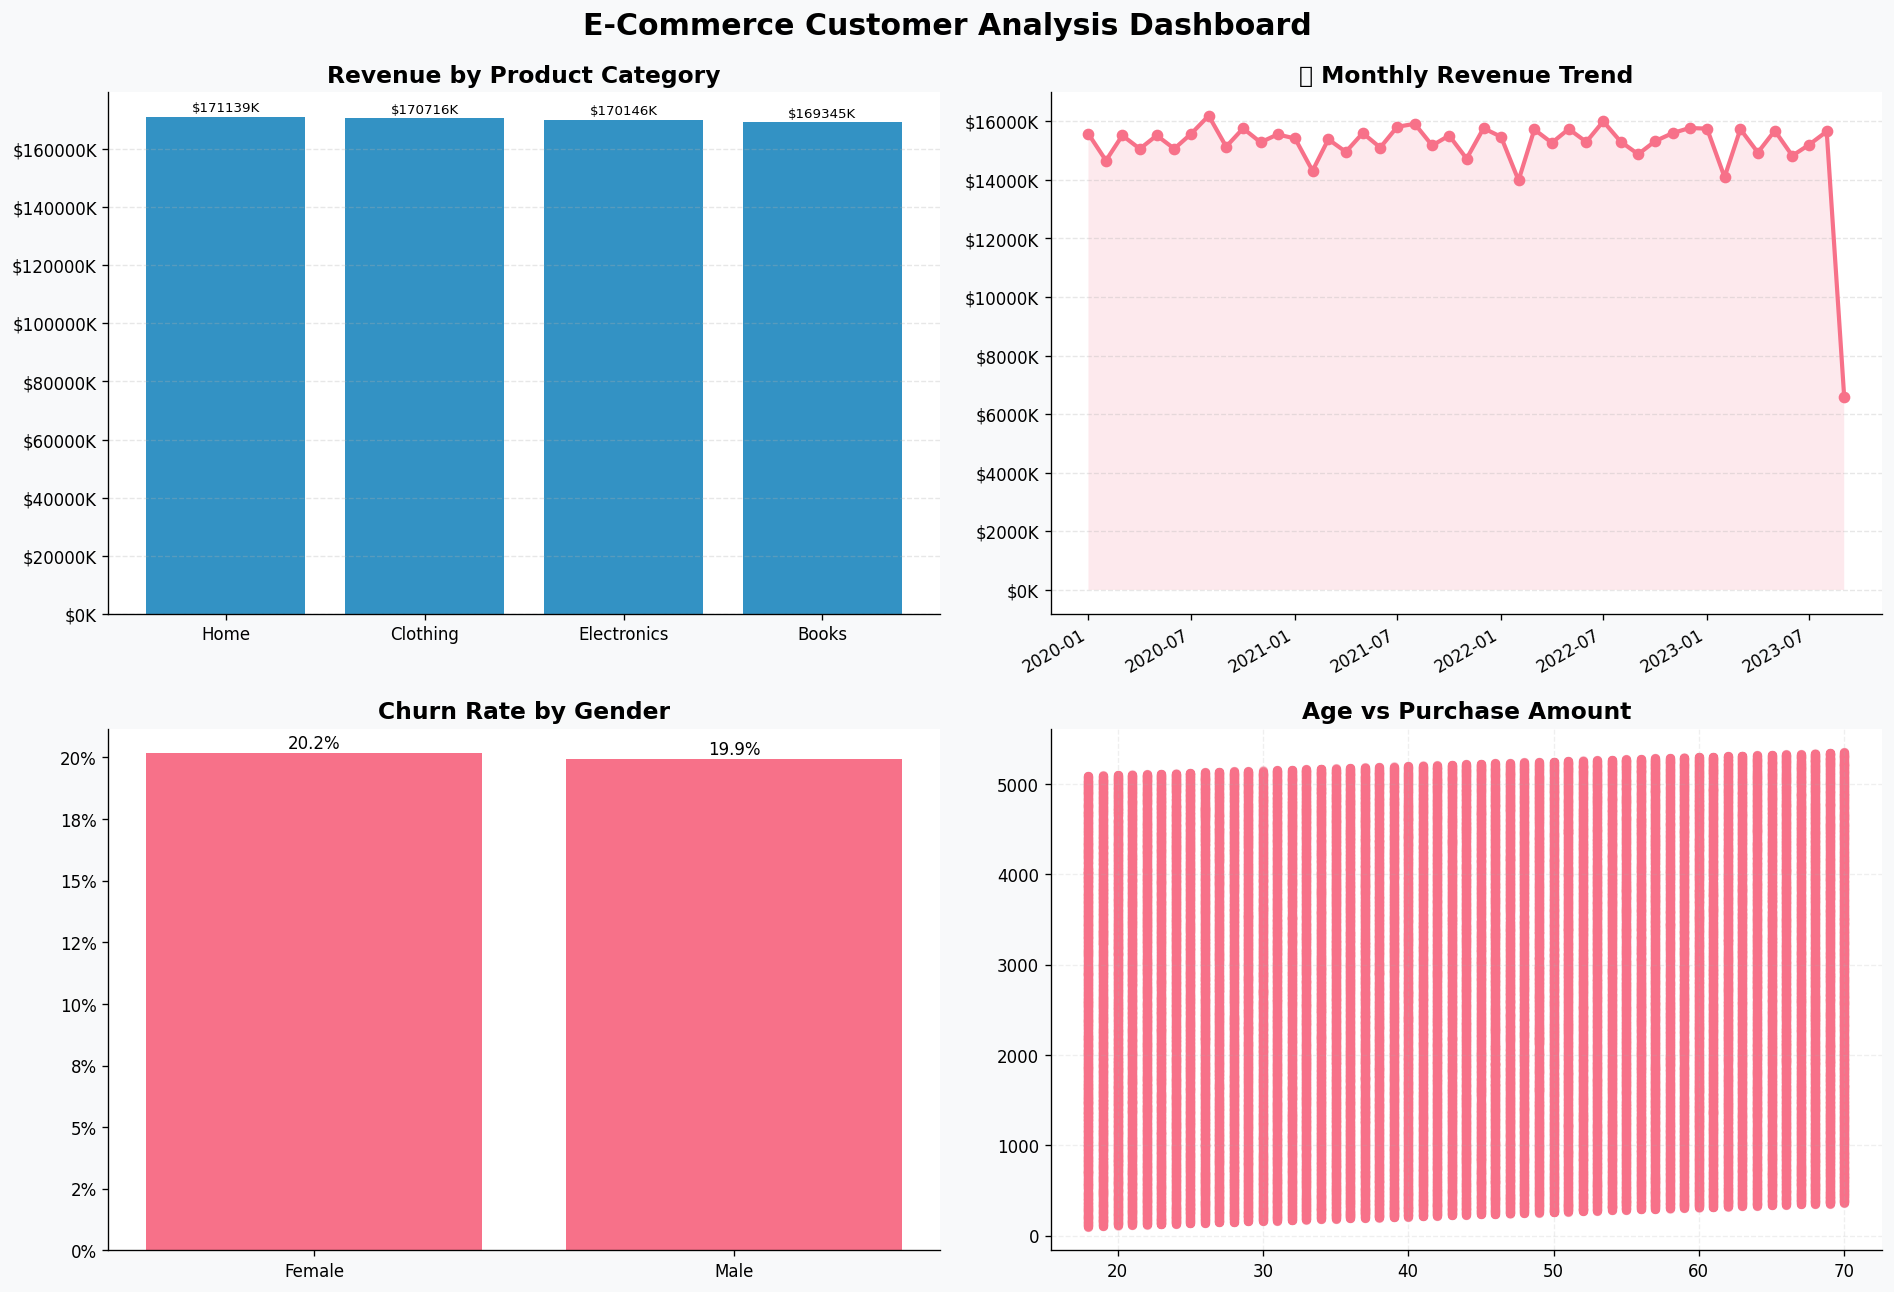

✅ Dashboard disimpan ke dashboard_charts.png


In [20]:
COLORS_CAT = {
    "Electronics": "#0077B6",
    "Clothing": "#E76F51",
    "Home": "#2A9D8F",
    "Beauty": "#8338EC"
}

FIG_COLOR = "#F8F9FA"

# =========================
# Monthly Revenue
# =========================
monthly = df.groupby(["Year", "Month"]).agg(
    Revenue=("Total Purchase Amount", "sum")
).reset_index()

monthly["Date"] = pd.to_datetime(
    monthly[["Year", "Month"]].assign(Day=1)
)

monthly = monthly.sort_values("Date")

# =========================
# Churn by Gender
# =========================
gender_churn = df.groupby("Gender")["Is_Churn"].mean() * 100

# =========================
# Revenue by Category
# =========================
sales_by_cat = df.groupby("Product Category").agg(
    Revenue=("Total Purchase Amount", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Revenue", ascending=False)

# =========================
# Figure
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(FIG_COLOR)

fig.suptitle(
    "E-Commerce Customer Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

# =====================================================
# Chart 1 — Revenue by Category
# =====================================================
ax1 = axes[0, 0]

cats = sales_by_cat.index.tolist()

bars = ax1.bar(
    cats,
    sales_by_cat["Revenue"] / 1000,
    color="#0077B6",
    alpha=0.8
)

ax1.set_title("Revenue by Product Category")

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax1.grid(axis="y", alpha=0.3, ls="--")

for bar in bars:
    h = bar.get_height()
    ax1.annotate(
        f"${h:.0f}K",
        xy=(bar.get_x() + bar.get_width()/2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

# =====================================================
# Chart 2 — Monthly Revenue Trend
# =====================================================
ax2 = axes[0, 1]

ax2.plot(
    monthly["Date"],
    monthly["Revenue"] / 1000,
    marker="o",
    linewidth=2.5
)

ax2.fill_between(
    monthly["Date"],
    monthly["Revenue"] / 1000,
    alpha=0.15
)

ax2.set_title("📈 Monthly Revenue Trend")

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}K")
)

ax2.grid(axis="y", alpha=0.3, ls="--")

plt.setp(
    ax2.get_xticklabels(),
    rotation=30,
    ha="right"
)

# =====================================================
# Chart 3 — Churn Rate by Gender
# =====================================================
ax3 = axes[1, 0]

bars3 = ax3.bar(
    gender_churn.index,
    gender_churn.values
)

ax3.set_title("Churn Rate by Gender")

ax3.xaxis.grid(False)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}%")
)

for bar in bars3:
    h = bar.get_height()
    ax3.annotate(
        f"{h:.1f}%",
        xy=(bar.get_x() + bar.get_width()/2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center"
    )

# =====================================================
# Chart 4 — Age vs Spending
# =====================================================
ax4 = axes[1, 1]

ax4.scatter(
    df["Age"],
    df["Total Purchase Amount"],
    alpha=0.3,
    s=20
)

ax4.set_title("Age vs Purchase Amount")

ax4.grid(alpha=0.2, ls="--")

# =====================================================
plt.tight_layout(pad=1.5)

plt.savefig(
    "dashboard_charts.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

print("✅ Dashboard disimpan ke dashboard_charts.png")

### Bonus: Heatmap Sales

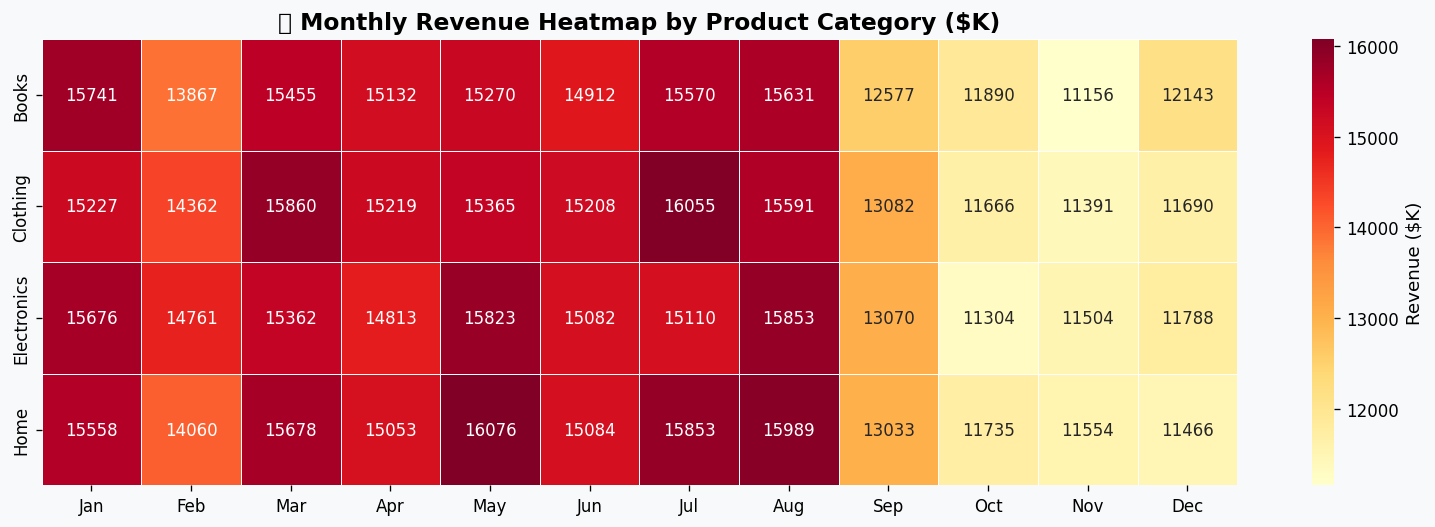

In [21]:
fig_h, ax_h = plt.subplots(figsize=(13, 4.5))

fig_h.patch.set_facecolor("#F8F9FA")
ax_h.set_facecolor("#F8F9FA")

hm = df.pivot_table(
    values="Total Purchase Amount",
    index="Product Category",
    columns="Month_Name",
    aggfunc="sum"
)

month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

hm = hm.reindex(
    columns=[m for m in month_order if m in hm.columns]
)

sns.heatmap(
    hm / 1e3,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax_h,
    cbar_kws={"label": "Revenue ($K)"}
)

ax_h.set_title(
    "🗓️ Monthly Revenue Heatmap by Product Category ($K)",
    fontsize=14,
    fontweight="bold"
)

ax_h.set_xlabel("")
ax_h.set_ylabel("")

plt.tight_layout()

plt.savefig(
    "heatmap_sales.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

## Cell 7 — Step 5: Business Insights
> ✏️ **Isi insight-mu di sini!** Ubah teks placeholder dengan temuan dari analisismu.

In [24]:
# =========================
# Insight Calculations
# =========================

high_spender = df.groupby("Customer Name")[
    "Total Purchase Amount"
].sum().mean()

most_category = df["Product Category"].value_counts().idxmax()

return_rate = df["Returns"].mean() * 100

churn_rate = df["Is_Churn"].mean() * 100

avg_purchase = df["Total Purchase Amount"].mean()

# =========================
# Business Insights
# =========================

print("=" * 55)
print("📊 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 55)

print(f"""
💡 INSIGHT 1 — CUSTOMER SPENDING
   Rata-rata total pembelian customer: ${high_spender:,.2f}

     Customer menunjukkan pola belanja aktif
     pada platform e-commerce.

💡 INSIGHT 2 — PRODUCT PERFORMANCE
   Kategori produk paling populer: {most_category}

     Fokus promosi dan stok pada kategori
     dengan demand tertinggi.

💡 INSIGHT 3 — CUSTOMER RETENTION
   Churn Rate : {churn_rate:.1f}%
   Return Rate: {return_rate:.1f}%

     Evaluasi pengalaman pelanggan untuk
     mengurangi churn dan return produk.

💡 REKOMENDASI:
   1. Tingkatkan promosi pada kategori terlaris
   2. Optimalkan customer retention program
   3. Analisis penyebab return product lebih lanjut
   4. Gunakan segmentasi customer berdasarkan spending
""")

📊 BUSINESS INSIGHTS & RECOMMENDATIONS

💡 INSIGHT 1 — CUSTOMER SPENDING
   Rata-rata total pembelian customer: $17,085.77

     Customer menunjukkan pola belanja aktif
     pada platform e-commerce.

💡 INSIGHT 2 — PRODUCT PERFORMANCE
   Kategori produk paling populer: Electronics

     Fokus promosi dan stok pada kategori
     dengan demand tertinggi.

💡 INSIGHT 3 — CUSTOMER RETENTION
   Churn Rate : 20.1%
   Return Rate: 50.1%

     Evaluasi pengalaman pelanggan untuk
     mengurangi churn dan return produk.

💡 REKOMENDASI:
   1. Tingkatkan promosi pada kategori terlaris
   2. Optimalkan customer retention program
   3. Analisis penyebab return product lebih lanjut
   4. Gunakan segmentasi customer berdasarkan spending



## Cell 8 — ✏️ YOUR TURN — Challenge Tasks

Selesaikan tasks berikut untuk memperkuat portfolio kamu:

In [26]:
# LEVEL 1: Wajib diselesaikan
# Task 1: Hitung CLV sederhana
#==============================

clv = df.groupby("Customer Name")[
    "Total Purchase Amount"
].agg(["sum", "count"])

clv.columns = ["Total_Spend", "Num_Orders"]

clv["Avg_Order"] = (
    clv["Total_Spend"] / clv["Num_Orders"]
)

print("Top 10 Customer berdasarkan Total Spend")
print(
    clv.sort_values(
        "Total_Spend",
        ascending=False
    ).head(10)
)

# Task 2: Top kategori dengan return tertinggi
#=============================================
returns_by_cat = df.groupby(
    "Product Category"
)["Returns"].mean().sort_values(ascending=False)

print("\nReturn Rate per Product Category")
print(returns_by_cat)

# Task 3: Spending berdasarkan Gender
#====================================
gender_perf = df.groupby("Gender").agg(
    Total_Revenue=("Total Purchase Amount", "sum"),
    Avg_Spending=("Total Purchase Amount", "mean"),
    Total_Quantity=("Quantity", "sum")
)

print("\nCustomer Spending by Gender")
print(gender_perf)

print("\n✅ Semua task berhasil dijalankan!")

Top 10 Customer berdasarkan Total Spend
                  Total_Spend  Num_Orders    Avg_Order
Customer Name                                         
Michael Johnson        339219         119  2850.579832
Michael Smith          321691         116  2773.198276
Michael Brown          299694         106  2827.301887
James Smith            265814          93  2858.215054
Michael Jones          265805          94  2827.712766
John Smith             258797          92  2813.010870
David Johnson          247292          88  2810.136364
John Johnson           234897          91  2581.285714
Michael Williams       221734          77  2879.662338
Jennifer Smith         220167          78  2822.653846

Return Rate per Product Category
Product Category
Books          0.503897
Electronics    0.501893
Home           0.499005
Clothing       0.498522
Name: Returns, dtype: float64

Customer Spending by Gender
        Total_Revenue  Avg_Spending  Total_Quantity
Gender                                    

---
## 🏁 Next Steps
1. Selesaikan **Challenge Tasks** di Cell 8
2. Simpan sebagai `ecommerce_analysis.ipynb`
3. Upload ke **GitHub** (buat repo: `ecommerce-sales-analysis`)
4. Screenshot **2–3 chart terbaik**
5. Buat **LinkedIn Post** dalam 7 hari!

```
Template Caption LinkedIn:
"[Hook sentence] 💡
📊 Analisis: Superstore Sales Dataset
🛠️ Tools: Python | Pandas | Seaborn
🔍 Key Findings:
• [Insight 1]
• [Insight 2]
• [Insight 3]
👉 Full notebook: [GitHub link]
#DataAnalytics #Python #Portfolio"
```

**Good luck! Kamu pasti bisa 🚀**